# 045. Counterfactual end-to-end: rerank + conflict-aware methods

Этот ноутбук проверяет специализированные методы для **counterfactual noise** поверх фиксированной retrieval-схемы `rerank`.

Идея эксперимента:

- retrieval-часть во всех методах одинаковая: `dense search → rerank → top-k context`;
- различается только способ финальной генерации ответа по уже reranked-контексту;
- проверяются уровни `0`, `40`, `80`;
- используется цикл по нескольким Groq-ключам: если один ключ упирается в лимит/quota, ноутбук переключается на следующий;
- все ответы и LLM-оценки кэшируются, поэтому прогон можно безопасно перезапускать.

Методы:

1. `rerank` — обычный balanced prompt;
2. `rerank_conflict_prompt` — промпт с явным предупреждением о противоречивых/контрафактических фрагментах;
3. `rerank_verify_then_answer` — внутренняя проверка конфликтов перед ответом;
4. `rerank_evidence_voting` — документное голосование: модель должна опираться на согласованность нескольких фрагментов.

## 0. Установка зависимостей и подключение Google Drive

In [1]:
!pip install -q qdrant-client fastembed groq tqdm tenacity flashrank pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 21.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 1. Импорты, пути и конфигурация

In [ ]:
import os
import re
import json
import time
import random
import string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =========================
# API keys and paths
# =========================
# Рекомендуемый вариант для Colab Secrets:
#   QDRANT_URL
#   QDRANT_API_KEY
#   GROQ_API_KEY_1, GROQ_API_KEY_2, ...
# или один ключ GROQ_API_KEY.
# Можно также использовать переменную окружения GROQ_API_KEYS="key1,key2,key3".
# Если удобно, можно временно вставить ключи в MANUAL_GROQ_API_KEYS, но не сохраняй ноутбук с реальными ключами в GitHub.
MANUAL_GROQ_API_KEYS = [

]

try:
    from google.colab import userdata
    QDRANT_URL = " "
    QDRANT_API_KEY = " "

    GROQ_API_KEYS = []
    try:
        v = os.environ.get("GROQ_API_KEY") or userdata.get("GROQ_API_KEY")
        if v:
            GROQ_API_KEYS.append(v.strip())
    except Exception:
        pass

    for i in range(1, 31):
        try:
            v = userdata.get(f"GROQ_API_KEY_{i}")
            if v:
                GROQ_API_KEYS.append(v.strip())
        except Exception:
            pass
except Exception:
    QDRANT_URL = os.environ.get("QDRANT_URL", "")
    QDRANT_API_KEY = os.environ.get("QDRANT_API_KEY", "")
    GROQ_API_KEYS = []

env_keys = os.environ.get("GROQ_API_KEYS", "")
if env_keys:
    GROQ_API_KEYS.extend([k.strip() for k in env_keys.split(",") if k.strip()])

GROQ_API_KEYS.extend([k.strip() for k in MANUAL_GROQ_API_KEYS if k.strip()])

# Удаляем дубликаты, сохраняя порядок.
_seen = set()
GROQ_API_KEYS = [k for k in GROQ_API_KEYS if not (k in _seen or _seen.add(k))]

assert QDRANT_URL, "Не найден QDRANT_URL. Укажи его в Colab Secrets или os.environ."
assert QDRANT_API_KEY, "Не найден QDRANT_API_KEY. Укажи его в Colab Secrets или os.environ."
assert GROQ_API_KEYS, "Не найден ни один Groq API key. Добавь GROQ_API_KEY_1/GROQ_API_KEY_2 в Colab Secrets."

ARTIFACTS_DIR = Path("/content/drive/MyDrive/rag_experiment/artifacts")
assert ARTIFACTS_DIR.exists(), f"Не найдена папка артефактов: {ARTIFACTS_DIR}"

NATURAL_CONFIG_PATH = ARTIFACTS_DIR / "end_to_end_replacement_collections_config.json"
assert NATURAL_CONFIG_PATH.exists(), (
    f"Не найден {NATURAL_CONFIG_PATH}. Сначала выполни 040_create_natural_replacement_noisy_collections.ipynb"
)

OUT_DIR = ARTIFACTS_DIR / "answers" / "end_to_end_counterfactual_rerank_conflict_methods"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EVAL_DIR = ARTIFACTS_DIR / "evaluations" / "end_to_end_counterfactual_rerank_conflict_methods"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = EVAL_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
RERANKER_MODEL = "ms-marco-MiniLM-L-12-v2"

GENERATOR_MODEL = os.environ.get("GENERATOR_MODEL", "llama-3.3-70b-versatile")
JUDGE_MODEL = os.environ.get("JUDGE_MODEL", "llama-3.1-8b-instant")

TOP_K_RETRIEVE = 20
TOP_K_FINAL = 5
GENERATOR_MAX_TOKENS = 120

NOISE_TYPE = "counterfactual"
NOISE_LEVELS = [0, 40, 80]

METHODS = [
    "rerank",
    "rerank_conflict_prompt",
    "rerank_verify_then_answer",
    "rerank_evidence_voting",
]

# Для быстрой проверки поставь, например, 20. Для полного прогона — None.
MAX_QUESTIONS = None

# Локальная TPM-пауза на каждый ключ. Реальные лимиты Groq всё равно обрабатываются автоматическим переключением ключей.
GROQ_TPM_BUDGET_PER_KEY = int(os.environ.get("GROQ_TPM_BUDGET_PER_KEY", "5500"))
GROQ_REQUEST_DELAY = float(os.environ.get("GROQ_REQUEST_DELAY", "0.35"))

print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("OUT_DIR:", OUT_DIR)
print("EVAL_DIR:", EVAL_DIR)
print("METHODS:", METHODS)
print("NOISE_LEVELS:", NOISE_LEVELS)
print("GENERATOR_MODEL:", GENERATOR_MODEL)
print("JUDGE_MODEL:", JUDGE_MODEL)
print("Groq keys loaded:", len(GROQ_API_KEYS))

ARTIFACTS_DIR: /content/drive/MyDrive/rag_experiment/artifacts
OUT_DIR: /content/drive/MyDrive/rag_experiment/artifacts/answers/end_to_end_counterfactual_rerank_conflict_methods
EVAL_DIR: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods
METHODS: ['rerank', 'rerank_conflict_prompt', 'rerank_verify_then_answer', 'rerank_evidence_voting']
NOISE_LEVELS: [0, 40, 80]
GENERATOR_MODEL: llama-3.3-70b-versatile
JUDGE_MODEL: llama-3.1-8b-instant
Groq keys loaded: 9


## 2. Загрузка вопросов, gold mapping и natural-коллекций

In [4]:
with open(ARTIFACTS_DIR / "questions.json", encoding="utf-8") as f:
    questions = json.load(f)
with open(ARTIFACTS_DIR / "gold_mapping.json", encoding="utf-8") as f:
    gold_mapping = json.load(f)
with open(NATURAL_CONFIG_PATH, encoding="utf-8") as f:
    natural_config = json.load(f)

if MAX_QUESTIONS is not None:
    questions = questions[:MAX_QUESTIONS]

COLLECTION_CLEAN = natural_config["collection_clean"]
COLLECTIONS_MAP = natural_config["collections"]

print(f"Вопросов: {len(questions)}")
print("Clean collection:", COLLECTION_CLEAN)
print("Counterfactual collections:")
for lvl in [40, 80]:
    key = f"counterfactual__{lvl}"
    print(f"  {lvl}: {COLLECTIONS_MAP.get(key)}")
print("Пример вопроса:", questions[0])

Вопросов: 100
Clean collection: rag_clean
Counterfactual collections:
  40: rag_noisy_counterfactual_replace_40
  80: rag_noisy_counterfactual_replace_80
Пример вопроса: {'id': '5ae0f73d55429920d5234252', 'question': 'Where was the Super Bowl, that Alan Faneca won, played ?', 'answer': 'Ford Field in Detroit', 'type': 'bridge', 'level': 'hard', 'gold_titles': ['Alan Faneca', 'Super Bowl XL']}


## 3. Подключение к Qdrant, Groq, embedder и reranker

In [5]:
from qdrant_client import QdrantClient
from fastembed import TextEmbedding
from groq import Groq, RateLimitError, APIError, BadRequestError
from flashrank import Ranker, RerankRequest

qdrant = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY, timeout=120)
groq_clients = [Groq(api_key=k) for k in GROQ_API_KEYS]
embedder = TextEmbedding(model_name=EMBEDDING_MODEL)

print("Проверка коллекций:")
for lvl in NOISE_LEVELS:
    cname = COLLECTION_CLEAN if lvl == 0 else COLLECTIONS_MAP[f"counterfactual__{lvl}"]
    info = qdrant.get_collection(cname)
    print(f"  lvl={lvl:>2} -> {cname}: {info.points_count} points")

print(f"Groq clients ready: {len(groq_clients)}")
print("Загрузка reranker...")
reranker = Ranker(model_name=RERANKER_MODEL)
print("✅ Ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Проверка коллекций:
  lvl= 0 -> rag_clean: 7997 points
  lvl=40 -> rag_noisy_counterfactual_replace_40: 7997 points
  lvl=80 -> rag_noisy_counterfactual_replace_80: 7998 points
Groq clients ready: 9
Загрузка reranker...



ms-marco-MiniLM-L-12-v2.zip:   0%|          | 0.00/21.6M [00:00<?, ?iB/s]
ms-marco-MiniLM-L-12-v2.zip: 100%|██████████| 21.6M/21.6M [00:00<00:00, 128MiB/s] 


✅ Ready


## 4. Groq multi-key pool: переключение ключей при лимитах

In [6]:
class ExperimentLimitReached(Exception):
    pass

class GroqTokenBudget:
    def __init__(self, tpm_limit):
        self.tpm_limit = tpm_limit
        self.usage = []

    def _prune(self):
        cutoff = time.time() - 60
        self.usage = [(t, n) for t, n in self.usage if t > cutoff]

    def wait_if_needed(self, est_tokens, key_label=""):
        self._prune()
        used = sum(n for _, n in self.usage)
        if used + est_tokens > self.tpm_limit and self.usage:
            wait_sec = max(0, 60 - (time.time() - self.usage[0][0])) + 1
            print(f"⏳ Local TPM budget {key_label}: sleep {wait_sec:.1f}s")
            time.sleep(wait_sec)
            self._prune()

    def record(self, tokens):
        self.usage.append((time.time(), tokens))

class GroqKeyPool:
    def __init__(self, clients, tpm_limit_per_key):
        self.clients = clients
        self.budgets = [GroqTokenBudget(tpm_limit_per_key) for _ in clients]
        self.disabled = [False for _ in clients]
        self.disable_reasons = [None for _ in clients]
        self.current_idx = 0

    def has_available(self):
        return any(not x for x in self.disabled)

    def _advance_to_available(self):
        n = len(self.clients)
        for _ in range(n):
            if not self.disabled[self.current_idx]:
                return True
            self.current_idx = (self.current_idx + 1) % n
        return False

    def current(self):
        if not self._advance_to_available():
            return None, None, None
        return self.current_idx, self.clients[self.current_idx], self.budgets[self.current_idx]

    def disable_current(self, reason):
        idx = self.current_idx
        self.disabled[idx] = True
        self.disable_reasons[idx] = str(reason)[:500]
        print(f"⚠️ Groq key #{idx + 1} reached limit/quota. Switching to next key.")
        self.current_idx = (self.current_idx + 1) % len(self.clients)

    def status(self):
        return pd.DataFrame([
            {"key_index": i + 1, "active": not disabled, "disabled_reason": self.disable_reasons[i]}
            for i, disabled in enumerate(self.disabled)
        ])

groq_key_pool = GroqKeyPool(groq_clients, GROQ_TPM_BUDGET_PER_KEY)

def estimate_tokens(text):
    return max(1, len(str(text)) // 4)

def is_groq_limit_error(exc):
    text = str(exc).lower()
    return (
        isinstance(exc, RateLimitError)
        or "rate limit" in text
        or "quota" in text
        or "tokens per minute" in text
        or "too many requests" in text
        or "requests per minute" in text
    )

def groq_complete(prompt, model=GENERATOR_MODEL, max_tokens=150, temperature=0.0):
    """LLM call with automatic failover across several Groq keys."""
    est = estimate_tokens(prompt) + max_tokens
    last_errors = []

    while groq_key_pool.has_available():
        idx, client, key_budget = groq_key_pool.current()
        if client is None:
            break
        key_label = f"key #{idx + 1}"
        key_budget.wait_if_needed(est, key_label=key_label)

        for attempt in range(2):
            try:
                resp = client.chat.completions.create(
                    model=model,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=temperature,
                    max_tokens=max_tokens,
                )
                time.sleep(GROQ_REQUEST_DELAY)
                used = getattr(resp, "usage", None)
                total_tokens = getattr(used, "total_tokens", None) if used else None
                if total_tokens is None:
                    total_tokens = est
                key_budget.record(total_tokens)
                return resp.choices[0].message.content.strip(), total_tokens
            except Exception as e:
                if is_groq_limit_error(e):
                    last_errors.append(f"{key_label}: {type(e).__name__}: {str(e)[:300]}")
                    groq_key_pool.disable_current(e)
                    break
                if isinstance(e, (APIError,)) and attempt == 0:
                    time.sleep(2)
                    continue
                raise

    print("\nGroq key pool status:")
    display(groq_key_pool.status())
    raise ExperimentLimitReached("All Groq API keys reached rate limit/quota. " + " | ".join(last_errors[-3:]))

print("Groq pool ready")
display(groq_key_pool.status())

Groq pool ready


,key_index,active,disabled_reason
0,1,True,None
1,2,True,None
2,3,True,None
3,4,True,None
4,5,True,None
5,6,True,None
6,7,True,None
7,8,True,None
8,9,True,None


## 5. Retrieval и rerank

In [7]:
def collection_for(noise_level):
    if noise_level == 0:
        return COLLECTION_CLEAN
    key = f"counterfactual__{noise_level}"
    if key not in COLLECTIONS_MAP:
        raise KeyError(f"Нет коллекции для {key}. Доступные ключи: {list(COLLECTIONS_MAP)}")
    return COLLECTIONS_MAP[key]

OWN_NOISE_ROLE = "injected_counterfactual"

def hit_to_doc(hit, collection_name, retrieved_by="dense"):
    p = hit.payload or {}
    return {
        "id": str(hit.id),
        "collection": collection_name,
        "title": p.get("title", ""),
        "text": p.get("text", ""),
        "role": p.get("role", "unknown"),
        "source_question_ids": p.get("source_question_ids", []),
        "source_question_id": p.get("source_question_id"),
        "based_on_title": p.get("based_on_title"),
        "noise_type": p.get("noise_type"),
        "score": float(hit.score) if getattr(hit, "score", None) is not None else None,
        "retrieved_by": retrieved_by,
    }

def doc_key(d):
    return f"{d.get('collection')}::{d.get('id')}::{d.get('title')}"

def dedupe_docs(docs):
    seen = set()
    out = []
    for d in docs:
        key = doc_key(d)
        if key in seen:
            continue
        seen.add(key)
        out.append(d)
    return out

def dense_search(query, collection_name, top_k=TOP_K_RETRIEVE):
    qvec = list(embedder.embed([query]))[0].tolist()
    hits = qdrant.query_points(
        collection_name=collection_name,
        query=qvec,
        limit=top_k,
        with_payload=True,
    ).points
    return [hit_to_doc(h, collection_name, retrieved_by="dense") for h in hits]

def rerank_docs(question, docs, top_k=TOP_K_FINAL):
    docs = dedupe_docs(docs)
    if not docs:
        return [], []
    passages = [
        {"id": i, "text": d.get("text", ""), "meta": {"title": d.get("title"), "role": d.get("role")}}
        for i, d in enumerate(docs)
    ]
    ranked = reranker.rerank(RerankRequest(query=question, passages=passages))
    reordered = [docs[r["id"]] for r in ranked]
    scores = [float(r["score"]) for r in ranked]
    return reordered[:top_k], scores[:top_k]

# Быстрая sanity-check выдачи
q0 = questions[0]
for lvl in NOISE_LEVELS:
    cname = collection_for(lvl)
    docs = dense_search(q0["question"], cname, top_k=5)
    final, scores = rerank_docs(q0["question"], docs, top_k=5)
    print(f"\nlvl={lvl}, collection={cname}")
    print("dense roles:", Counter(d["role"] for d in docs))
    print("rerank roles:", Counter(d["role"] for d in final))
    for d in final[:3]:
        print(" -", d["role"], "|", d["title"][:80])


lvl=0, collection=rag_clean
dense roles: Counter({'gold': 3, 'distractor': 1, 'background': 1})
rerank roles: Counter({'gold': 3, 'distractor': 1, 'background': 1})
 - gold | Alan Faneca
 - gold | Alan Faneca
 - distractor | Super Bowl XVIII

lvl=40, collection=rag_noisy_counterfactual_replace_40
dense roles: Counter({'gold': 3, 'distractor': 1, 'background': 1})
rerank roles: Counter({'gold': 3, 'distractor': 1, 'background': 1})
 - gold | Alan Faneca
 - gold | Alan Faneca
 - distractor | Super Bowl XVIII

lvl=80, collection=rag_noisy_counterfactual_replace_80
dense roles: Counter({'injected_counterfactual': 3, 'distractor': 1, 'background': 1})
rerank roles: Counter({'injected_counterfactual': 3, 'distractor': 1, 'background': 1})
 - injected_counterfactual | Alan Faneca [CF-0]
 - injected_counterfactual | Alan Faneca [CF-0]
 - distractor | Super Bowl XVIII


## 6. Промпты и методы генерации поверх одного reranked-контекста

In [8]:
def format_context(docs, max_chars_per_doc=1200):
    parts = []
    for i, d in enumerate(docs, 1):
        text = (d.get("text") or "")[:max_chars_per_doc]
        title = d.get("title", "")
        role = d.get("role", "")
        parts.append(f"[{i}] Title: {title}\nRole: {role}\nText: {text}")
    return "\n\n".join(parts)

BALANCED_PROMPT = """You are a question-answering assistant. Answer the question using ONLY the provided context.

The context may contain noisy, irrelevant, duplicated, corrupted, or contradictory fragments.
Your task is to identify the most relevant evidence and provide the most likely answer based only on that evidence.

Important rules:
1. Do not use outside knowledge.
2. Do not mention that the context is noisy unless it is necessary.
3. If the context contains at least some relevant evidence, give the best possible short answer.
4. If several fragments conflict, prefer the fragment that is most directly related to the question.
5. Answer exactly "I don't know" only if the provided context contains no relevant information for answering the question.
6. Keep the answer concise: usually 1-5 words, unless a short phrase is necessary.

Question:
{question}

Context:
{context}

Answer:"""

CONFLICT_PROMPT = """You are a question-answering assistant. Answer the question using ONLY the provided context.

The context may contain counterfactual or contradictory fragments. Some fragments may look highly relevant but contain false facts.

Rules:
1. Do not use outside knowledge.
2. Find fragments that directly answer the question.
3. If fragments conflict, do not automatically trust the first or most confident fragment.
4. Prefer the answer supported by multiple consistent fragments or by the most specific/direct evidence.
5. Ignore isolated claims that conflict with stronger or repeated evidence.
6. Answer exactly "I don't know" only if there is no relevant evidence at all.
7. Return only the final short answer.

Question:
{question}

Context:
{context}

Final short answer:"""

VERIFY_PROMPT = """You are a careful QA verifier. Use ONLY the provided context.

The context may include counterfactual fragments. Think internally through these steps:
- identify candidate answers from the context;
- check whether the candidate answers are supported or contradicted by other fragments;
- prefer the answer with the strongest direct support;
- if evidence is conflicting, choose the answer with the best support rather than refusing.

Do not reveal your reasoning. Return only the final short answer.
Say exactly "I don't know" only if the context contains no relevant evidence.

Question:
{question}

Context:
{context}

Final short answer:"""

VOTING_PROMPT = """You are a document-level evidence voting QA system. Use ONLY the provided context fragments.

The context may contain counterfactual fragments. Work internally as follows:
1. For each numbered fragment, decide whether it directly answers the question.
2. Extract the short answer supported by each relevant fragment.
3. Compare candidate answers across fragments.
4. Prefer the answer supported by the largest number of consistent relevant fragments.
5. If there is a tie, prefer the answer supported by the most specific and direct fragment.
6. Do not use outside knowledge.

Return only the final short answer. Say exactly "I don't know" only if no fragment contains relevant evidence.

Question:
{question}

Context fragments:
{context}

Final short answer:"""

def parse_final_answer(text):
    text = (text or "").strip()
    # на случай если модель всё же вернула строку вида Final answer: ...
    m = re.search(r"final\s+(short\s+)?answer\s*:\s*(.+)$", text, flags=re.I | re.S)
    if m:
        return m.group(2).strip()
    # оставляем только первую непустую строку, если модель случайно дала пояснения
    lines = [x.strip() for x in text.splitlines() if x.strip()]
    if not lines:
        return text
    if len(lines) > 1:
        # если первая строка выглядит как reasoning, лучше взять последнюю короткую
        short_lines = [x for x in lines if len(x.split()) <= 12]
        return short_lines[-1] if short_lines else lines[-1]
    return lines[0]

def call_answer_prompt(prompt_template, question, context_docs, max_tokens=GENERATOR_MAX_TOKENS):
    prompt = prompt_template.format(question=question, context=format_context(context_docs))
    out, tokens = groq_complete(prompt, model=GENERATOR_MODEL, max_tokens=max_tokens, temperature=0.0)
    return parse_final_answer(out), tokens, out

def get_reranked_context(q, collection_name):
    candidates = dense_search(q["question"], collection_name, top_k=TOP_K_RETRIEVE)
    final_context, rerank_scores = rerank_docs(q["question"], candidates, top_k=TOP_K_FINAL)
    return candidates, final_context, rerank_scores

def method_rerank(q, collection_name):
    candidates, final_context, rerank_scores = get_reranked_context(q, collection_name)
    answer, tokens, raw = call_answer_prompt(BALANCED_PROMPT, q["question"], final_context)
    return {"answer": answer, "raw_answer": raw, "candidates": candidates, "final_context": final_context,
            "rerank_scores": rerank_scores, "tokens": tokens, "extra_calls": 0}

def method_rerank_conflict_prompt(q, collection_name):
    candidates, final_context, rerank_scores = get_reranked_context(q, collection_name)
    answer, tokens, raw = call_answer_prompt(CONFLICT_PROMPT, q["question"], final_context)
    return {"answer": answer, "raw_answer": raw, "candidates": candidates, "final_context": final_context,
            "rerank_scores": rerank_scores, "tokens": tokens, "extra_calls": 0}

def method_rerank_verify_then_answer(q, collection_name):
    candidates, final_context, rerank_scores = get_reranked_context(q, collection_name)
    answer, tokens, raw = call_answer_prompt(VERIFY_PROMPT, q["question"], final_context, max_tokens=140)
    return {"answer": answer, "raw_answer": raw, "candidates": candidates, "final_context": final_context,
            "rerank_scores": rerank_scores, "tokens": tokens, "extra_calls": 0}

def method_rerank_evidence_voting(q, collection_name):
    candidates, final_context, rerank_scores = get_reranked_context(q, collection_name)
    answer, tokens, raw = call_answer_prompt(VOTING_PROMPT, q["question"], final_context, max_tokens=160)
    return {"answer": answer, "raw_answer": raw, "candidates": candidates, "final_context": final_context,
            "rerank_scores": rerank_scores, "tokens": tokens, "extra_calls": 0}

METHOD_REGISTRY = {
    "rerank": method_rerank,
    "rerank_conflict_prompt": method_rerank_conflict_prompt,
    "rerank_verify_then_answer": method_rerank_verify_then_answer,
    "rerank_evidence_voting": method_rerank_evidence_voting,
}

## 7. Retrieval-метрики и сериализация документов

In [9]:
def clean_title(title):
    return re.sub(r"\s*\[(CF|STR|SEM)-\d+\]\s*$", "", title or "").strip()

def title_matches_gold(title, gold_title):
    t = clean_title(title)
    g = (gold_title or "").strip()
    return bool(g) and (t == g or g in t or t in g)

def get_gold_titles(qid):
    item = gold_mapping.get(qid, {})
    return set(item.get("gold_titles", []))

def doc_is_true_gold(doc, qid, gold_titles):
    if doc.get("role") != "gold":
        return False
    source_ids = set(str(x) for x in (doc.get("source_question_ids") or []))
    if str(qid) in source_ids:
        return True
    return any(title_matches_gold(doc.get("title", ""), gt) for gt in gold_titles)

def doc_is_related_to_gold(doc, qid, gold_titles):
    if doc_is_true_gold(doc, qid, gold_titles):
        return True
    based = doc.get("based_on_title")
    if based and any(title_matches_gold(based, gt) for gt in gold_titles):
        return True
    return False

def gold_titles_found(docs, qid, gold_titles, mode="true_gold"):
    found = set()
    for d in docs:
        for gt in gold_titles:
            if mode == "true_gold":
                ok = doc_is_true_gold(d, qid, {gt})
            elif mode == "related":
                ok = doc_is_related_to_gold(d, qid, {gt})
            else:
                raise ValueError(mode)
            if ok:
                found.add(gt)
    return found

def rank_of_first_match(docs, qid, gold_titles, mode="true_gold"):
    for i, d in enumerate(docs, start=1):
        if mode == "true_gold" and doc_is_true_gold(d, qid, gold_titles):
            return i
        if mode == "related" and doc_is_related_to_gold(d, qid, gold_titles):
            return i
    return None

def retrieval_metrics(qid, docs, noise_level):
    gold_titles = get_gold_titles(qid)
    n_gold = max(1, len(gold_titles))
    rows = {}

    for k in [3, 5, 10]:
        top = docs[:k]
        true_found = gold_titles_found(top, qid, gold_titles, mode="true_gold")
        rel_found = gold_titles_found(top, qid, gold_titles, mode="related")
        own_noise_hits = sum(1 for d in top if d.get("role") == OWN_NOISE_ROLE)
        injected_hits = sum(1 for d in top if str(d.get("role", "")).startswith("injected_"))
        rows[f"gold_recall_at_{k}"] = len(true_found) / n_gold
        rows[f"related_recall_at_{k}"] = len(rel_found) / n_gold
        rows[f"own_noise_hits_at_{k}"] = own_noise_hits
        rows[f"injected_hits_at_{k}"] = injected_hits
        rows[f"own_noise_share_at_{k}"] = own_noise_hits / max(k, 1)
        rows[f"roles_at_{k}"] = dict(Counter(d.get("role", "unknown") for d in top))

    best_rank = rank_of_first_match(docs, qid, gold_titles, mode="true_gold")
    rel_best_rank = rank_of_first_match(docs, qid, gold_titles, mode="related")
    rows["gold_best_rank"] = best_rank
    rows["gold_mrr"] = 0.0 if best_rank is None else 1.0 / best_rank
    rows["related_best_rank"] = rel_best_rank
    rows["related_mrr"] = 0.0 if rel_best_rank is None else 1.0 / rel_best_rank
    rows["gold_titles"] = sorted(gold_titles)
    return rows

def serialize_docs(docs):
    return [
        {
            "id": d.get("id"),
            "collection": d.get("collection"),
            "title": d.get("title"),
            "role": d.get("role"),
            "text": d.get("text"),
            "score": d.get("score"),
            "retrieved_by": d.get("retrieved_by"),
            "source_question_ids": d.get("source_question_ids"),
            "source_question_id": d.get("source_question_id"),
            "based_on_title": d.get("based_on_title"),
            "noise_type": d.get("noise_type"),
        }
        for d in docs
    ]

## 8. Запуск генерации с кэшированием по конфигурациям

In [10]:
def config_path(method, noise_level):
    return OUT_DIR / f"{method}__counterfactual__lvl{noise_level}.json"

def load_config_cache(method, noise_level):
    p = config_path(method, noise_level)
    if p.exists():
        with open(p, encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_config_cache(method, noise_level, cache):
    p = config_path(method, noise_level)
    tmp = p.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)
    tmp.replace(p)

def run_one(method_name, noise_level, q):
    qid = q["id"]
    collection_name = collection_for(noise_level)
    fn = METHOD_REGISTRY[method_name]
    t0 = time.time()
    try:
        result = fn(q, collection_name)
        candidate_metrics = retrieval_metrics(qid, result.get("candidates", []), noise_level)
        final_metrics = retrieval_metrics(qid, result.get("final_context", []), noise_level)
        return {
            "qid": qid,
            "question": q["question"],
            "gold": q["answer"],
            "method": method_name,
            "noise_type": "counterfactual",
            "noise_level": noise_level,
            "collection": collection_name,
            "predicted": result["answer"],
            "raw_answer": result.get("raw_answer"),
            "candidates": serialize_docs(result.get("candidates", [])),
            "final_context": serialize_docs(result.get("final_context", [])),
            "candidate_metrics": candidate_metrics,
            "final_context_metrics": final_metrics,
            "latency_sec": round(time.time() - t0, 2),
            "tokens": result.get("tokens"),
            "extra_calls": result.get("extra_calls", 0),
            "rerank_scores": result.get("rerank_scores"),
            "error": None,
        }
    except ExperimentLimitReached:
        raise
    except Exception as e:
        return {
            "qid": qid,
            "question": q["question"],
            "gold": q["answer"],
            "method": method_name,
            "noise_type": "counterfactual",
            "noise_level": noise_level,
            "collection": collection_name,
            "predicted": None,
            "latency_sec": round(time.time() - t0, 2),
            "error": f"{type(e).__name__}: {str(e)[:500]}",
        }

def run_config(method, noise_level, verbose=True):
    cache = load_config_cache(method, noise_level)
    pending = [q for q in questions if q["id"] not in cache]
    desc = f"{method}/counterfactual/lvl{noise_level}"

    if not pending:
        if verbose:
            print(f"  [{desc}] уже готово: {len(cache)}/{len(questions)}")
        return cache

    if verbose:
        print(f"  [{desc}] обработано {len(cache)}/{len(questions)}, осталось {len(pending)}")

    for q in tqdm(pending, desc=desc, leave=False):
        try:
            rec = run_one(method, noise_level, q)
        except ExperimentLimitReached as e:
            save_config_cache(method, noise_level, cache)
            print("\n⛔ Groq limit/quota reached. Прогон остановлен безопасно.")
            print(f"   Конфигурация: {desc}")
            print(f"   Уже сохранено: {len(cache)}/{len(questions)}")
            print("   Перезапусти эту ячейку позже: готовые qid будут пропущены по кэшу.")
            raise SystemExit(str(e))

        cache[q["id"]] = rec
        save_config_cache(method, noise_level, cache)

        if verbose:
            tqdm.write(f"\n[QID: {q['id']}] {desc}")
            tqdm.write(f"Q: {rec.get('question')}")
            tqdm.write(f"Gold: {rec.get('gold')}")
            if rec.get("error"):
                tqdm.write(f"ERROR: {rec['error']}")
            else:
                fm = rec.get("final_context_metrics", {})
                tqdm.write(f"A: {rec.get('predicted')}")
                tqdm.write(
                    f"final R@5={fm.get('gold_recall_at_5')}, "
                    f"MRR={fm.get('gold_mrr'):.3f}, noise@5={fm.get('own_noise_hits_at_5')}"
                )

    return cache

### Запуск генерации

In [11]:
for method in METHODS:
    print("=" * 100)
    print("METHOD:", method)
    for lvl in NOISE_LEVELS:
        run_config(method, lvl, verbose=True)

print("✅ Генерация завершена")

METHOD: rerank
  [rerank/counterfactual/lvl0] уже готово: 100/100
  [rerank/counterfactual/lvl40] уже готово: 100/100
  [rerank/counterfactual/lvl80] уже готово: 100/100
METHOD: rerank_conflict_prompt
  [rerank_conflict_prompt/counterfactual/lvl0] уже готово: 100/100
  [rerank_conflict_prompt/counterfactual/lvl40] уже готово: 100/100
  [rerank_conflict_prompt/counterfactual/lvl80] уже готово: 100/100
METHOD: rerank_verify_then_answer
  [rerank_verify_then_answer/counterfactual/lvl0] уже готово: 100/100
  [rerank_verify_then_answer/counterfactual/lvl40] уже готово: 100/100
  [rerank_verify_then_answer/counterfactual/lvl80] уже готово: 100/100
METHOD: rerank_evidence_voting
  [rerank_evidence_voting/counterfactual/lvl0] уже готово: 100/100
  [rerank_evidence_voting/counterfactual/lvl40] уже готово: 100/100
  [rerank_evidence_voting/counterfactual/lvl80] обработано 81/100, осталось 19


rerank_evidence_voting/counterfactual/lvl80:   0%|          | 0/19 [00:00<?, ?it/s]


[QID: 5ae1bf46554299234fd042e6] rerank_evidence_voting/counterfactual/lvl80
Q: Are both Jack and Coke and Clover Club Cocktail cocktails?
Gold: yes
A: Yes.
final R@5=1.0, MRR=1.000, noise@5=1

[QID: 5a7790ed5542992a6e59defb] rerank_evidence_voting/counterfactual/lvl80
Q: Name three common things that are used in playing Monopoly and King of Tokyo?
Gold: dice, cards, and boards
A: Dice, cards, and boards.
final R@5=0.0, MRR=0.000, noise@5=3

[QID: 5a7322a25542991f9a20c634] rerank_evidence_voting/counterfactual/lvl80
Q: Was the Metropolitan Life Insurance Company Tower [Met Life Tower] or the 15 Hudson Yards building designed by the firm of Napoleon LeBrun & Sons?
Gold: The Metropolitan Life Insurance Company Tower
A: Met Life Tower.
final R@5=0.0, MRR=0.000, noise@5=2

[QID: 5ae4581e55429970de88d92f] rerank_evidence_voting/counterfactual/lvl80
Q: Which city is under Jining, Kaiyuan, Liaoning or Yanzhou District?
Gold: Yanzhou
A: Yanzhou District
final R@5=1.0, MRR=1.000, noise@5=1

[QI

## 9. Базовые answer-метрики: EM, F1, I don't know

In [12]:
def normalize_answer(s):
    if s is None:
        return ""
    s = str(s).lower().strip()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in set(string.punctuation))
    s = " ".join(s.split())
    return s

def exact_match(pred, gold):
    return float(normalize_answer(pred) == normalize_answer(gold))

def token_f1(pred, gold):
    pred_tokens = normalize_answer(pred).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    n_common = sum(common.values())
    if n_common == 0:
        return 0.0
    precision = n_common / len(pred_tokens)
    recall = n_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

IDK_PATTERNS = [
    r"^i\s*(do\s*not|don't|dont)\s*know\.?$",
    r"^unknown\.?$",
    r"^not\s+enough\s+information\.?$",
    r"^cannot\s+answer\.?$",
    r"^can't\s+answer\.?$",
    r"^no\s+answer\.?$",
]

def is_idk_answer(s):
    s_norm = normalize_answer(s)
    if not s_norm:
        return False
    raw = str(s or "").strip().lower()
    if any(re.search(p, raw) for p in IDK_PATTERNS):
        return True
    return "i dont know" in s_norm or "not enough information" in s_norm or "cannot answer" in s_norm

def iter_answer_records():
    for method in METHODS:
        for lvl in NOISE_LEVELS:
            path = config_path(method, lvl)
            if not path.exists():
                continue
            with open(path, encoding="utf-8") as f:
                cache = json.load(f)
            for qid, rec in cache.items():
                yield rec

records = list(iter_answer_records())
rows = []
for rec in records:
    pred = rec.get("predicted")
    gold = rec.get("gold")
    err = rec.get("error")
    row = {
        "qid": rec.get("qid"),
        "method": rec.get("method"),
        "noise_type": rec.get("noise_type"),
        "noise_level": rec.get("noise_level"),
        "collection": rec.get("collection"),
        "generation_error": err,
        "valid_answer": err is None and pred is not None,
        "predicted": pred,
        "gold": gold,
        "EM": exact_match(pred, gold) if err is None else np.nan,
        "F1": token_f1(pred, gold) if err is None else np.nan,
        "is_idk": is_idk_answer(pred) if err is None else False,
        "tokens": rec.get("tokens"),
        "latency_sec": rec.get("latency_sec"),
    }
    for prefix, metrics_key in [("cand", "candidate_metrics"), ("final", "final_context_metrics")]:
        m = rec.get(metrics_key, {}) or {}
        for key, value in m.items():
            if isinstance(value, (dict, list)):
                continue
            row[f"{prefix}_{key}"] = value
    rows.append(row)

base_df = pd.DataFrame(rows)
out_all = EVAL_DIR / "045_counterfactual_rerank_methods_all_records_basic_metrics.csv"
base_df.to_csv(out_all, index=False)
print(f"Всего записей: {len(base_df)}")
print(f"Сохранено: {out_all}")
display(base_df.head())

Всего записей: 1200
Сохранено: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/045_counterfactual_rerank_methods_all_records_basic_metrics.csv


,qid,method,noise_type,noise_level,collection,generation_error,valid_answer,predicted,gold,EM,...,final_own_noise_share_at_5,final_gold_recall_at_10,final_related_recall_at_10,final_own_noise_hits_at_10,final_injected_hits_at_10,final_own_noise_share_at_10,final_gold_best_rank,final_gold_mrr,final_related_best_rank,final_related_mrr
0,5ae0f73d55429920d5234252,rerank,counterfactual,0,rag_clean,None,True,Ford Field,Ford Field in Detroit,0.0,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1,1.0
1,5ae0cddc55429945ae959459,rerank,counterfactual,0,rag_clean,None,True,35 people,35 people,1.0,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1,1.0
2,5ae4563e5542996836b02c7f,rerank,counterfactual,0,rag_clean,None,True,Over 600 stores,over 600 stores,1.0,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1,1.0
3,5a8725a15542996432c57230,rerank,counterfactual,0,rag_clean,None,True,Shootout.,the shootout,1.0,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1,1.0
4,5a8468c95542990548d0b2b1,rerank,counterfactual,0,rag_clean,None,True,Secker and Warburg,Fredric John Warburg,0.0,...,0.0,1.0,1.0,0,0,0.0,1.0,1.0,1,1.0


## 10. Сводка по базовым метрикам

In [13]:
def summarize(df):
    g = df.groupby(["method", "noise_type", "noise_level"], dropna=False)
    summary = g.agg(
        n_records=("qid", "count"),
        n_valid=("valid_answer", "sum"),
        n_errors=("generation_error", lambda x: x.notna().sum()),
        n_idk=("is_idk", "sum"),
        EM=("EM", "mean"),
        F1=("F1", "mean"),
        final_gold_recall_at_3=("final_gold_recall_at_3", "mean"),
        final_gold_recall_at_5=("final_gold_recall_at_5", "mean"),
        final_gold_mrr=("final_gold_mrr", "mean"),
        final_related_recall_at_5=("final_related_recall_at_5", "mean"),
        final_own_noise_hits_at_5=("final_own_noise_hits_at_5", "mean"),
        final_own_noise_hits_at_10=("final_own_noise_hits_at_10", "mean"),
        tokens_mean=("tokens", "mean"),
        latency_mean=("latency_sec", "mean"),
    ).reset_index()
    summary["idk_rate"] = summary["n_idk"] / summary["n_valid"].replace(0, np.nan)
    return summary.sort_values(["noise_level", "method"])

summary_df = summarize(base_df)
out_summary = EVAL_DIR / "045_counterfactual_rerank_methods_summary_basic.csv"
summary_df.to_csv(out_summary, index=False)
print(f"Сводка сохранена: {out_summary}")
display(summary_df)

Сводка сохранена: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/045_counterfactual_rerank_methods_summary_basic.csv


,method,noise_type,noise_level,n_records,n_valid,n_errors,n_idk,EM,F1,final_gold_recall_at_3,final_gold_recall_at_5,final_gold_mrr,final_related_recall_at_5,final_own_noise_hits_at_5,final_own_noise_hits_at_10,tokens_mean,latency_mean,idk_rate
0,rerank,counterfactual,0,100,100,0,1,0.52,0.721873,1.00,1.00,0.968333,1.00,0.00,0.00,715.96,8.1522,0.01
3,rerank_conflict_prompt,counterfactual,0,100,100,0,9,0.49,0.687215,1.00,1.00,0.968333,1.00,0.00,0.00,694.01,8.5817,0.09
6,rerank_evidence_voting,counterfactual,0,100,100,0,7,0.50,0.693716,1.00,1.00,0.968333,1.00,0.00,0.00,690.06,8.5037,0.07
9,rerank_verify_then_answer,counterfactual,0,100,100,0,5,0.51,0.708802,1.00,1.00,0.968333,1.00,0.00,0.00,662.56,7.7259,0.05
1,rerank,counterfactual,40,100,100,0,1,0.43,0.624651,0.79,0.80,0.690833,0.98,0.77,0.77,720.62,8.8284,0.01
4,rerank_conflict_prompt,counterfactual,40,100,100,0,13,0.43,0.603514,0.79,0.80,0.690833,0.98,0.77,0.77,699.36,8.1423,0.13
7,rerank_evidence_voting,counterfactual,40,100,100,0,10,0.44,0.598916,0.79,0.80,0.690833,0.98,0.77,0.77,692.57,8.3602,0.10
10,rerank_verify_then_answer,counterfactual,40,100,100,0,6,0.44,0.614930,0.79,0.80,0.690833,0.98,0.77,0.77,666.75,7.6595,0.06
2,rerank,counterfactual,80,100,100,0,0,0.37,0.523554,0.37,0.37,0.333333,0.95,1.54,1.54,726.73,8.6610,0.00
5,rerank_conflict_prompt,counterfactual,80,100,100,0,12,0.31,0.473026,0.37,0.37,0.333333,0.95,1.54,1.54,707.06,6.2915,0.12


## 11. LLM-as-a-judge: correctness и faithfulness

In [14]:
CORRECTNESS_PROMPT = """You are evaluating a QA system.
Determine whether the predicted answer is semantically correct compared to the gold answer.

Question: {question}
Gold answer: {gold}
Predicted answer: {predicted}

Return JSON only with keys:
- score: 1 if correct, 0 if incorrect
- reason: short explanation
"""

FAITHFULNESS_PROMPT = """You are evaluating whether an answer is supported by the provided context.
The answer should be considered faithful only if the context directly supports it.

Question: {question}
Context:
{context}

Answer: {predicted}

Return JSON only with keys:
- score: 1 if fully supported, 0 if not supported or contradicted
- reason: short explanation
"""

def safe_json_parse(text):
    text = (text or "").strip()
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, flags=re.S)
        if m:
            try:
                return json.loads(m.group(0))
            except Exception:
                pass
    return {"score": None, "reason": text[:500]}

def eval_cache_path(kind):
    return EVAL_DIR / f"045_llm_{kind}_cache.json"

def load_eval_cache(kind):
    p = eval_cache_path(kind)
    if p.exists():
        with open(p, encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_eval_cache(kind, cache):
    p = eval_cache_path(kind)
    tmp = p.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)
    tmp.replace(p)

def record_key(rec):
    return f"{rec.get('method')}::counterfactual::{rec.get('noise_level')}::{rec.get('qid')}"

def judge_correctness(rec):
    prompt = CORRECTNESS_PROMPT.format(
        question=rec.get("question"),
        gold=rec.get("gold"),
        predicted=rec.get("predicted"),
    )
    out, tokens = groq_complete(prompt, model=JUDGE_MODEL, max_tokens=120, temperature=0.0)
    parsed = safe_json_parse(out)
    parsed["tokens"] = tokens
    return parsed

def judge_faithfulness(rec):
    prompt = FAITHFULNESS_PROMPT.format(
        question=rec.get("question"),
        context=format_context(rec.get("final_context", []), max_chars_per_doc=900),
        predicted=rec.get("predicted"),
    )
    out, tokens = groq_complete(prompt, model=JUDGE_MODEL, max_tokens=140, temperature=0.0)
    parsed = safe_json_parse(out)
    parsed["tokens"] = tokens
    return parsed

def run_llm_eval(kind, judge_fn):
    cache = load_eval_cache(kind)
    valid_records = [r for r in records if not r.get("error") and r.get("predicted")]
    pending = [r for r in valid_records if record_key(r) not in cache]
    print(f"{kind}: готово {len(cache)}/{len(valid_records)}, осталось {len(pending)}")

    for rec in tqdm(pending, desc=f"LLM {kind}"):
        key = record_key(rec)
        try:
            cache[key] = judge_fn(rec)
            cache[key].update({
                "qid": rec.get("qid"),
                "method": rec.get("method"),
                "noise_type": "counterfactual",
                "noise_level": rec.get("noise_level"),
            })
            save_eval_cache(kind, cache)
        except ExperimentLimitReached as e:
            save_eval_cache(kind, cache)
            print("\n⛔ Groq limit/quota reached during evaluation. Сохранено, можно продолжить позже.")
            raise SystemExit(str(e))
    return cache

### Запуск LLM-оценки

In [15]:
correctness_cache = run_llm_eval("correctness", judge_correctness)
faithfulness_cache = run_llm_eval("faithfulness", judge_faithfulness)
print("✅ LLM-оценка завершена")

correctness: готово 0/1200, осталось 1200


LLM correctness:   0%|          | 0/1200 [00:00<?, ?it/s]

⏳ Local TPM budget key #1: sleep 37.8s
⏳ Local TPM budget key #1: sleep 1.1s
⏳ Local TPM budget key #1: sleep 1.4s
⏳ Local TPM budget key #1: sleep 1.1s
⏳ Local TPM budget key #1: sleep 1.1s
⏳ Local TPM budget key #1: sleep 31.5s
⏳ Local TPM budget key #1: sleep 1.5s
⏳ Local TPM budget key #1: sleep 1.2s
⏳ Local TPM budget key #1: sleep 4.5s
faithfulness: готово 0/1200, осталось 1200


LLM faithfulness:   0%|          | 0/1200 [00:00<?, ?it/s]

⏳ Local TPM budget key #1: sleep 1.4s
⏳ Local TPM budget key #1: sleep 2.2s
⏳ Local TPM budget key #1: sleep 1.7s
⏳ Local TPM budget key #1: sleep 2.1s
⏳ Local TPM budget key #1: sleep 2.0s
⏳ Local TPM budget key #1: sleep 2.0s
⏳ Local TPM budget key #1: sleep 2.0s
⏳ Local TPM budget key #1: sleep 2.0s
⏳ Local TPM budget key #1: sleep 2.5s
⏳ Local TPM budget key #1: sleep 1.7s
⏳ Local TPM budget key #1: sleep 2.1s
⏳ Local TPM budget key #1: sleep 1.7s
⏳ Local TPM budget key #1: sleep 2.1s
⏳ Local TPM budget key #1: sleep 3.2s
⏳ Local TPM budget key #1: sleep 3.2s
⏳ Local TPM budget key #1: sleep 1.2s
⏳ Local TPM budget key #1: sleep 2.0s
⏳ Local TPM budget key #1: sleep 2.5s
⏳ Local TPM budget key #1: sleep 2.8s
⏳ Local TPM budget key #1: sleep 1.5s
⏳ Local TPM budget key #1: sleep 2.7s
⏳ Local TPM budget key #1: sleep 1.8s
⏳ Local TPM budget key #1: sleep 1.3s
⏳ Local TPM budget key #1: sleep 2.3s
⏳ Local TPM budget key #1: sleep 1.9s
⏳ Local TPM budget key #1: sleep 2.2s
⏳ Local TPM 

## 12. Объединение LLM-judge с общей таблицей

In [16]:
def cache_to_df(cache, prefix):
    rows = []
    for key, v in cache.items():
        parts = key.split("::")
        row = {
            "eval_key": key,
            "method": v.get("method") or (parts[0] if len(parts) > 0 else None),
            "noise_type": v.get("noise_type") or (parts[1] if len(parts) > 1 else None),
            "noise_level": int(v.get("noise_level") or (parts[2] if len(parts) > 2 else 0)),
            "qid": v.get("qid") or (parts[3] if len(parts) > 3 else None),
            f"{prefix}_score": v.get("score"),
            f"{prefix}_reason": v.get("reason"),
            f"{prefix}_tokens": v.get("tokens"),
        }
        rows.append(row)
    return pd.DataFrame(rows)

correctness_cache = load_eval_cache("correctness")
faithfulness_cache = load_eval_cache("faithfulness")

judge_df = base_df.copy()
judge_df["eval_key"] = judge_df.apply(lambda r: f"{r['method']}::counterfactual::{r['noise_level']}::{r['qid']}", axis=1)

if correctness_cache:
    cdf = cache_to_df(correctness_cache, "correctness")
    judge_df = judge_df.merge(cdf[["eval_key", "correctness_score", "correctness_reason"]], on="eval_key", how="left")
if faithfulness_cache:
    fdf = cache_to_df(faithfulness_cache, "faithfulness")
    judge_df = judge_df.merge(fdf[["eval_key", "faithfulness_score", "faithfulness_reason"]], on="eval_key", how="left")

for col in ["correctness_score", "faithfulness_score"]:
    if col in judge_df.columns:
        judge_df[col] = pd.to_numeric(judge_df[col], errors="coerce")

out_judge = EVAL_DIR / "045_counterfactual_rerank_methods_all_records_with_llm_judge.csv"
judge_df.to_csv(out_judge, index=False)
print(f"Сохранено: {out_judge}")

group_cols = ["method", "noise_type", "noise_level"]
agg = {
    "qid": "count",
    "EM": "mean",
    "F1": "mean",
    "is_idk": "mean",
    "final_gold_recall_at_5": "mean",
    "final_gold_mrr": "mean",
    "final_own_noise_hits_at_5": "mean",
}
if "correctness_score" in judge_df.columns:
    agg["correctness_score"] = "mean"
if "faithfulness_score" in judge_df.columns:
    agg["faithfulness_score"] = "mean"

llm_summary = judge_df.groupby(group_cols, dropna=False).agg(agg).reset_index().rename(columns={"qid": "n", "is_idk": "idk_rate"})
out_llm_summary = EVAL_DIR / "045_counterfactual_rerank_methods_summary_with_llm_judge.csv"
llm_summary.to_csv(out_llm_summary, index=False)
print(f"LLM summary сохранена: {out_llm_summary}")
display(llm_summary.sort_values(["noise_level", "method"]))

Сохранено: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/045_counterfactual_rerank_methods_all_records_with_llm_judge.csv
LLM summary сохранена: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/045_counterfactual_rerank_methods_summary_with_llm_judge.csv


,method,noise_type,noise_level,n,EM,F1,idk_rate,final_gold_recall_at_5,final_gold_mrr,final_own_noise_hits_at_5,correctness_score,faithfulness_score
0,rerank,counterfactual,0,100,0.52,0.721873,0.01,1.00,0.968333,0.00,0.727273,0.714286
3,rerank_conflict_prompt,counterfactual,0,100,0.49,0.687215,0.09,1.00,0.968333,0.00,0.710000,0.734694
6,rerank_evidence_voting,counterfactual,0,100,0.50,0.693716,0.07,1.00,0.968333,0.00,0.700000,0.727273
9,rerank_verify_then_answer,counterfactual,0,100,0.51,0.708802,0.05,1.00,0.968333,0.00,0.730000,0.717172
1,rerank,counterfactual,40,100,0.43,0.624651,0.01,0.80,0.690833,0.77,0.636364,0.585859
4,rerank_conflict_prompt,counterfactual,40,100,0.43,0.603514,0.13,0.80,0.690833,0.77,0.580000,0.646465
7,rerank_evidence_voting,counterfactual,40,100,0.44,0.598916,0.10,0.80,0.690833,0.77,0.580000,0.585859
10,rerank_verify_then_answer,counterfactual,40,100,0.44,0.614930,0.06,0.80,0.690833,0.77,0.630000,0.616162
2,rerank,counterfactual,80,100,0.37,0.523554,0.00,0.37,0.333333,1.54,0.520000,0.581633
5,rerank_conflict_prompt,counterfactual,80,100,0.31,0.473026,0.12,0.37,0.333333,1.54,0.490000,0.595960


## 13. Графики и сравнение с обычным rerank

In [17]:
plot_df = llm_summary.copy() if "llm_summary" in globals() else summary_df.copy()

METHOD_ORDER = METHODS
plot_df["method"] = pd.Categorical(plot_df["method"], categories=METHOD_ORDER, ordered=True)
plot_df = plot_df.sort_values(["noise_level", "method"])

plot_df

,method,noise_type,noise_level,n,EM,F1,idk_rate,final_gold_recall_at_5,final_gold_mrr,final_own_noise_hits_at_5,correctness_score,faithfulness_score
0,rerank,counterfactual,0,100,0.52,0.721873,0.01,1.00,0.968333,0.00,0.727273,0.714286
3,rerank_conflict_prompt,counterfactual,0,100,0.49,0.687215,0.09,1.00,0.968333,0.00,0.710000,0.734694
9,rerank_verify_then_answer,counterfactual,0,100,0.51,0.708802,0.05,1.00,0.968333,0.00,0.730000,0.717172
6,rerank_evidence_voting,counterfactual,0,100,0.50,0.693716,0.07,1.00,0.968333,0.00,0.700000,0.727273
1,rerank,counterfactual,40,100,0.43,0.624651,0.01,0.80,0.690833,0.77,0.636364,0.585859
4,rerank_conflict_prompt,counterfactual,40,100,0.43,0.603514,0.13,0.80,0.690833,0.77,0.580000,0.646465
10,rerank_verify_then_answer,counterfactual,40,100,0.44,0.614930,0.06,0.80,0.690833,0.77,0.630000,0.616162
7,rerank_evidence_voting,counterfactual,40,100,0.44,0.598916,0.10,0.80,0.690833,0.77,0.580000,0.585859
2,rerank,counterfactual,80,100,0.37,0.523554,0.00,0.37,0.333333,1.54,0.520000,0.581633
5,rerank_conflict_prompt,counterfactual,80,100,0.31,0.473026,0.12,0.37,0.333333,1.54,0.490000,0.595960


/tmp/ipykernel_531/352518284.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = plot_df.pivot_table(index="method", columns="noise_level", values=metric, aggfunc="mean")


Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/plots/045_EM_by_level.png


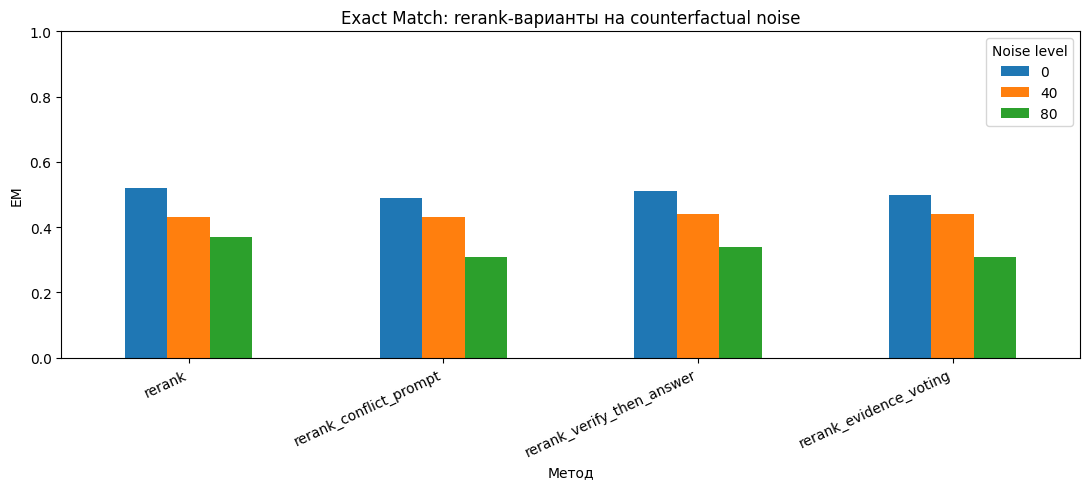

/tmp/ipykernel_531/352518284.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = plot_df.pivot_table(index="method", columns="noise_level", values=metric, aggfunc="mean")


Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/plots/045_F1_by_level.png


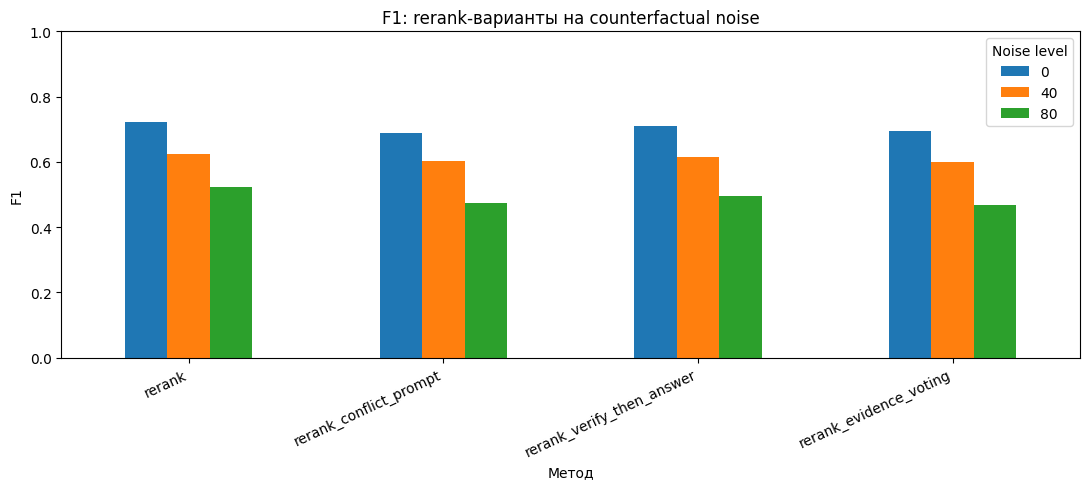

/tmp/ipykernel_531/352518284.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = plot_df.pivot_table(index="method", columns="noise_level", values=metric, aggfunc="mean")


Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/plots/045_idk_rate_by_level.png


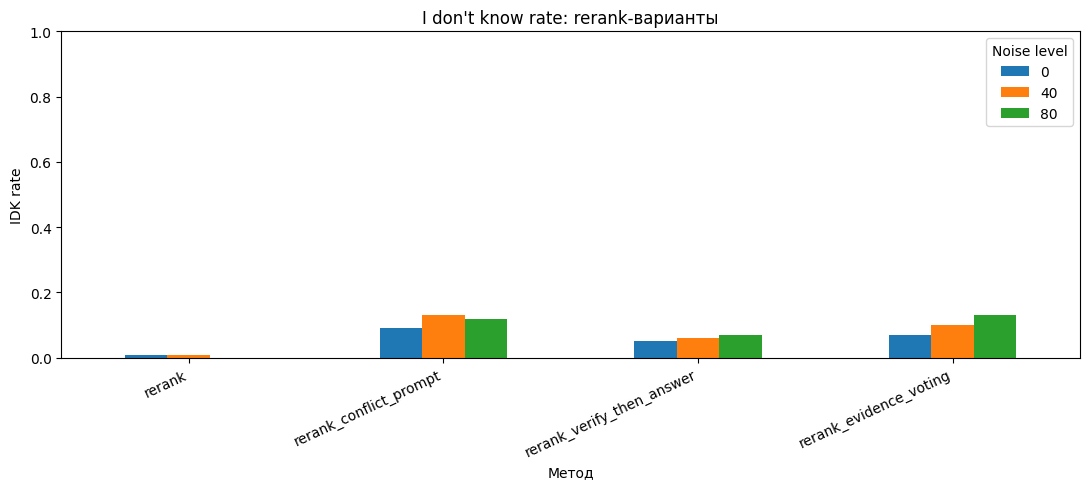

/tmp/ipykernel_531/352518284.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = plot_df.pivot_table(index="method", columns="noise_level", values=metric, aggfunc="mean")


Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/plots/045_correctness_score_by_level.png


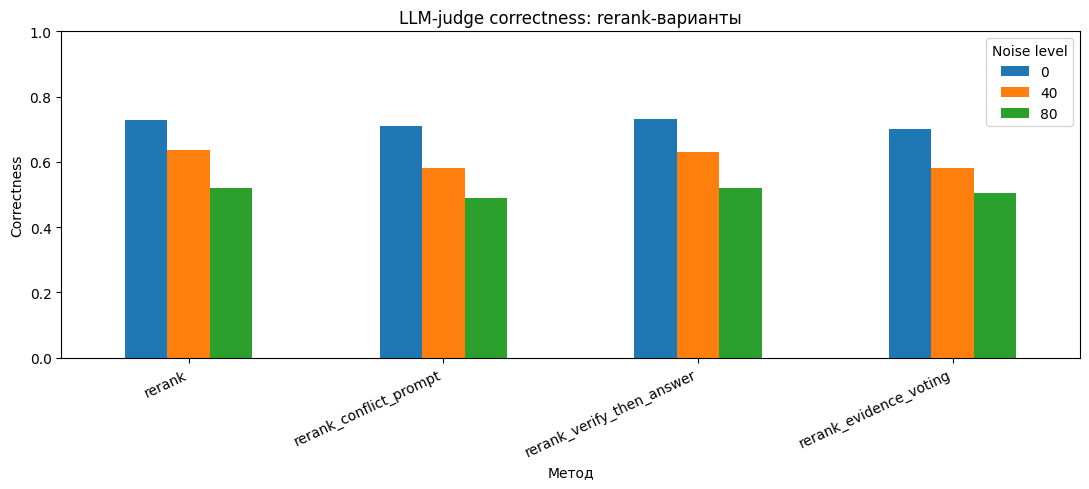

/tmp/ipykernel_531/352518284.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = plot_df.pivot_table(index="method", columns="noise_level", values=metric, aggfunc="mean")


Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/plots/045_faithfulness_score_by_level.png


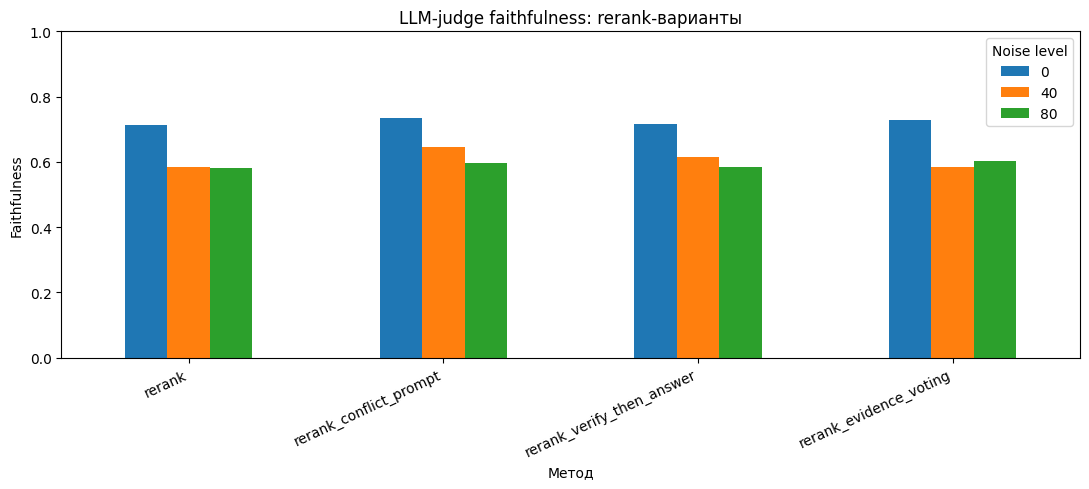

In [18]:
def save_and_show(fig, filename):
    path = PLOTS_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print("Saved:", path)
    plt.show()

def bar_metric_by_level(metric, title, ylabel=None, ylim=(0, 1)):
    if metric not in plot_df.columns:
        print(f"Нет метрики {metric}")
        return
    pivot = plot_df.pivot_table(index="method", columns="noise_level", values=metric, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(11, 5))
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Метод")
    ax.set_ylabel(ylabel or metric)
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(title="Noise level")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    save_and_show(fig, f"045_{metric}_by_level.png")

bar_metric_by_level("EM", "Exact Match: rerank-варианты на counterfactual noise", "EM")
bar_metric_by_level("F1", "F1: rerank-варианты на counterfactual noise", "F1")
bar_metric_by_level("idk_rate", "I don't know rate: rerank-варианты", "IDK rate")
bar_metric_by_level("correctness_score", "LLM-judge correctness: rerank-варианты", "Correctness")
bar_metric_by_level("faithfulness_score", "LLM-judge faithfulness: rerank-варианты", "Faithfulness")

Delta сохранено: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/045_counterfactual_rerank_methods_delta_vs_rerank.csv


,noise_level,method,delta_EM,delta_F1,delta_correctness_score,delta_faithfulness_score
0,0,rerank,0.00,0.000000,0.000000,0.000000
1,0,rerank_conflict_prompt,-0.03,-0.034658,-0.017273,0.020408
2,0,rerank_verify_then_answer,-0.01,-0.013071,0.002727,0.002886
3,0,rerank_evidence_voting,-0.02,-0.028157,-0.027273,0.012987
4,40,rerank,0.00,0.000000,0.000000,0.000000
5,40,rerank_conflict_prompt,0.00,-0.021137,-0.056364,0.060606
6,40,rerank_verify_then_answer,0.01,-0.009720,-0.006364,0.030303
7,40,rerank_evidence_voting,0.01,-0.025735,-0.056364,0.000000
8,80,rerank,0.00,0.000000,0.000000,0.000000
9,80,rerank_conflict_prompt,-0.06,-0.050527,-0.030000,0.014327


Saved: /content/drive/MyDrive/rag_experiment/artifacts/evaluations/end_to_end_counterfactual_rerank_conflict_methods/plots/045_delta_correctness_vs_rerank.png


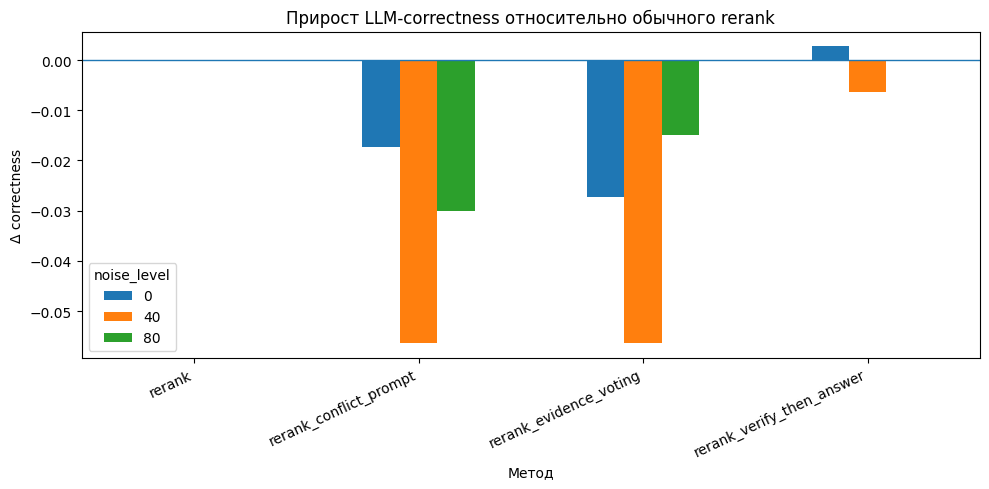

In [19]:
# Прирост относительно обычного rerank для каждого уровня шума
metrics_for_delta = [m for m in ["EM", "F1", "correctness_score", "faithfulness_score"] if m in plot_df.columns]

delta_rows = []
for lvl in sorted(plot_df["noise_level"].dropna().unique()):
    base = plot_df[(plot_df["noise_level"] == lvl) & (plot_df["method"] == "rerank")]
    if base.empty:
        continue
    base = base.iloc[0]
    for _, row in plot_df[plot_df["noise_level"] == lvl].iterrows():
        out = {"noise_level": lvl, "method": row["method"]}
        for m in metrics_for_delta:
            out[f"delta_{m}"] = row[m] - base[m]
        delta_rows.append(out)

delta_df = pd.DataFrame(delta_rows)
out_delta = EVAL_DIR / "045_counterfactual_rerank_methods_delta_vs_rerank.csv"
delta_df.to_csv(out_delta, index=False)
print("Delta сохранено:", out_delta)
display(delta_df)

if "correctness_score" in plot_df.columns:
    pivot = delta_df.pivot_table(index="method", columns="noise_level", values="delta_correctness_score", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", ax=ax)
    ax.axhline(0, linewidth=1)
    ax.set_title("Прирост LLM-correctness относительно обычного rerank")
    ax.set_xlabel("Метод")
    ax.set_ylabel("Δ correctness")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    save_and_show(fig, "045_delta_correctness_vs_rerank.png")

In [20]:
# Таблица: кто лучший по correctness/F1 на каждом уровне
for metric in ["correctness_score", "F1", "EM"]:
    if metric not in plot_df.columns:
        continue
    print("\nЛучшие методы по", metric)
    best = plot_df.sort_values(["noise_level", metric], ascending=[True, False]).groupby("noise_level").head(1)
    display(best[["noise_level", "method", metric, "F1", "EM", "idk_rate"] + (["faithfulness_score"] if "faithfulness_score" in best.columns else [])])


Лучшие методы по correctness_score


,noise_level,method,correctness_score,F1,EM,idk_rate,faithfulness_score
9,0,rerank_verify_then_answer,0.730000,0.708802,0.51,0.05,0.717172
1,40,rerank,0.636364,0.624651,0.43,0.01,0.585859
2,80,rerank,0.520000,0.523554,0.37,0.00,0.581633



Лучшие методы по F1


,noise_level,method,F1,F1,EM,idk_rate,faithfulness_score
0,0,rerank,0.721873,0.721873,0.52,0.01,0.714286
1,40,rerank,0.624651,0.624651,0.43,0.01,0.585859
2,80,rerank,0.523554,0.523554,0.37,0.00,0.581633



Лучшие методы по EM


,noise_level,method,EM,F1,EM,idk_rate,faithfulness_score
0,0,rerank,0.52,0.721873,0.52,0.01,0.714286
10,40,rerank_verify_then_answer,0.44,0.614930,0.44,0.06,0.616162
2,80,rerank,0.37,0.523554,0.37,0.00,0.581633
